In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


##Part A - Data Preparation

 Load Dataset

In [62]:
mark_sentiment = pd.read_csv('https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf')
trade_data = pd.read_csv('https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs')

number of rows/columns and missing values / duplicates


In [63]:
print(mark_sentiment.shape)
print(trade_data.shape)
print(mark_sentiment.isnull().sum())
print(trade_data.isnull().sum())
print(mark_sentiment.duplicated().sum())
print(trade_data.duplicated().sum())

(2644, 4)
(211224, 16)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [64]:
mark_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [65]:
trade_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

## Date Conversion and Dataset Alignment

Trading timestamps are converted to daily dates and merged with sentiment data.

In [66]:
trade_data['Timestamp IST'] = pd.to_datetime(
    trade_data['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trade_data['date'] = trade_data['Timestamp IST'].dt.date

mark_sentiment['date'] = pd.to_datetime(mark_sentiment['date']).dt.date

In [67]:
merged = trade_data.merge(
    mark_sentiment,
    left_on='date',
    right_on='date',
    how='left'
)
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## Feature Engineering

The following metrics are created:

- Daily PnL
- Win Rate
- Average Trade Size
- Trades Per Day
- Long/Short Ratio

In [68]:
daily_pnl = trade_data.groupby(['Account', 'date'])['Closed PnL'].sum()

print(daily_pnl.head())


Account                                     date      
0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0
                                            2024-11-17        0.0
                                            2024-11-18        0.0
                                            2024-11-22   -21227.0
                                            2024-11-26     1603.1
Name: Closed PnL, dtype: float64


In [69]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = (
    merged.groupby('Account')['win']
    .mean()
    * 100
)
avg_trade_size = (
    trade_data.groupby('Account')['Size Tokens']
    .mean()
)

In [70]:
avg_size_usd = (
    trade_data.groupby('Account')['Size USD']
    .mean()
)

In [71]:
trades_per_day = (
    trade_data.groupby('date')
    .size()
    .reset_index(name='trade_count')
)
trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [72]:
longs = trade_data['Direction'].str.contains(
    'Long',
    case=False,
    na=False
).sum()

shorts = trade_data['Direction'].str.contains(
    'Short',
    case=False,
    na=False
).sum()

ratio = longs / shorts

print("Longs:", longs)
print("Shorts:", shorts)
print("Ratio:", ratio)

Longs: 98700
Shorts: 75882
Ratio: 1.3007037242033683


# Part B — Analysis

## Question 1

Does performance differ between Fear and Greed periods?

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


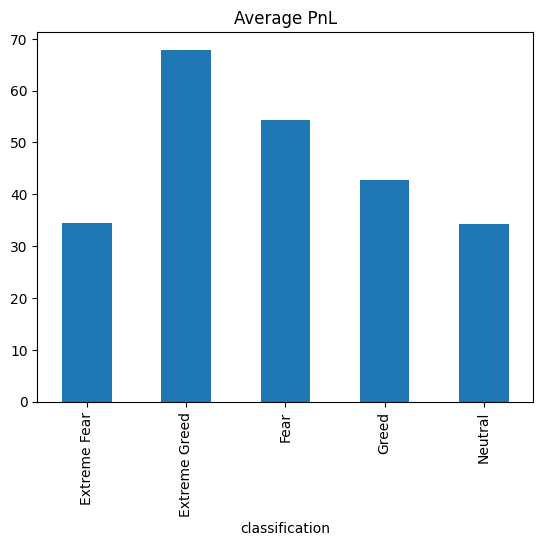

In [73]:
pnl_sentiment = (
    merged.groupby('classification')
    ['Closed PnL']
    .mean()
)
print(pnl_sentiment)
pnl_sentiment.plot(kind='bar')
plt.title("Average PnL")
plt.show()

### Interpretation

Greed periods generally show higher average profitability than Fear periods.


classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


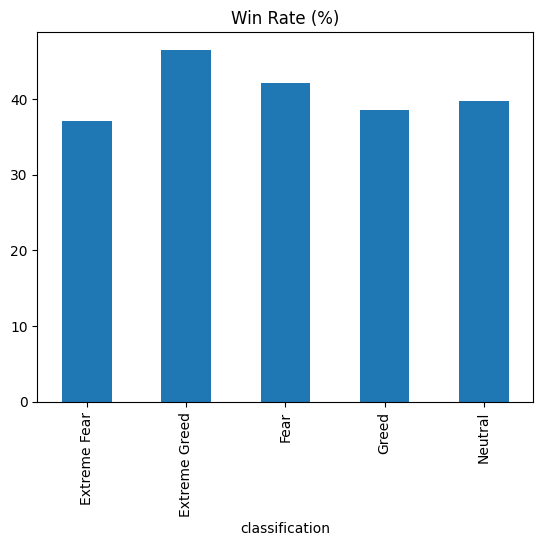

In [74]:
win_sentiment = (merged.groupby('classification')['win'].mean()* 100)

print(win_sentiment)
win_sentiment.plot(kind='bar')
plt.title("Win Rate (%)")
plt.show()

### Interpretation

Win rates across Extreme grid is higher compared to other sentiment

classification
Extreme Fear     -77308.420095
Extreme Greed   -132271.000000
Fear            -108604.496278
Greed           -358963.139984
Neutral         -113601.020138
Name: Closed PnL, dtype: float64


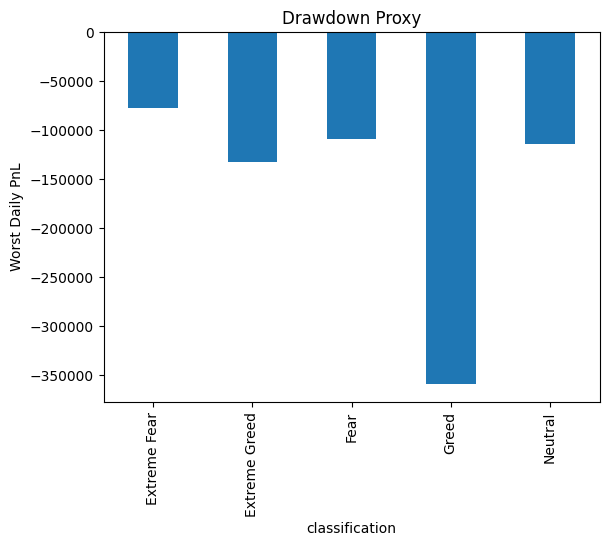

In [75]:
daily_pnl_sentiment = (
    merged.groupby(
        ['Account','date','classification']
    )['Closed PnL']
    .sum()
    .reset_index()
)

drawdown_proxy = (
    daily_pnl_sentiment.groupby(
        'classification'
    )['Closed PnL']
    .min()
)

print(drawdown_proxy)

drawdown_proxy.plot(kind='bar')
plt.title("Drawdown Proxy")
plt.ylabel("Worst Daily PnL")
plt.show()

## Question 2

Do traders change behavior based on sentiment?

In [76]:
daily_trades = (merged.groupby(['date','classification']).size().reset_index(name = 'Trade Count'))
freq = (daily_trades.groupby('classification')['Trade Count'].mean())
print(freq)

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: Trade Count, dtype: float64


Trading activity was highest during Extreme Fear (1528 trades/day) and much lower during Greed periods. This suggests traders become more active during uncertain and volatile markets.

In [77]:
size_sentiment = ( merged.groupby('classification')['Size USD'].mean())

print(size_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [78]:
bias = pd.crosstab(
    merged['classification'],
    merged['Direction'],
    normalize='index'
) * 100

print(bias)

Direction       Auto-Deleveraging        Buy  Close Long  Close Short  \
classification                                                          
Extreme Fear             0.000000   3.771028   29.163551    14.565421   
Extreme Greed            0.000000  12.832567   17.968594    16.245749   
Fear                     0.000000   5.186215   27.912091    14.911784   
Greed                    0.015904   9.313560   15.899648    22.507604   
Neutral                  0.000000   7.655363   26.516478    15.523006   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                     0.000000      0.023364  32.733645   
Extreme Greed                    0.000000      0.017504  15.753151   
Fear                             0.000000      0.022640  28.824167   
Greed                            0.001988      0.031807  16.985070   
Neutral                          0.000000      0.039803  27.124131  

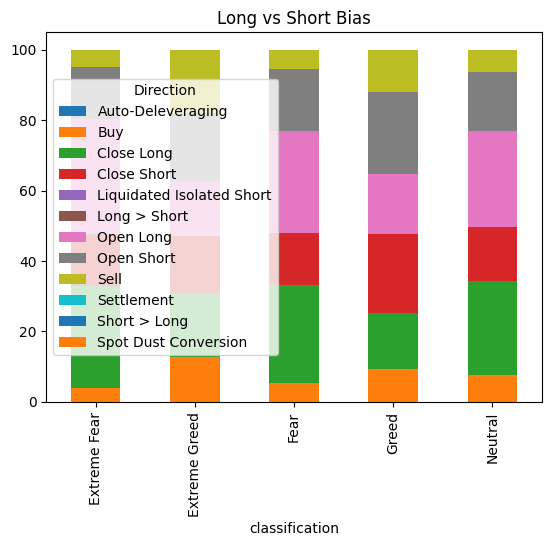

In [79]:
bias.plot(kind='bar', stacked=True)
plt.title("Long vs Short Bias")
plt.show()

## Interpretation

The largest average position sizes were taken during Fear periods, indicating greater capital allocation despite negative market sentiment.

## Question 3

Trader Segmentation

In [80]:
trade_counts = (merged.groupby('Account').size().reset_index(name='Trades'))
median_trades = trade_counts['Trades'].median()
trade_counts['Segment'] = np.where(trade_counts['Trades'] > median_trades,'Frequent','Infrequent')

In [81]:
merged = merged.merge(trade_counts[['Account','Segment']],on='Account')

In [82]:
freq_segment = (merged.groupby('Segment').agg({
        'Closed PnL':'mean',
        'win':'mean'
    })
)

freq_segment['win'] *= 100

print(freq_segment)

            Closed PnL        win
Segment                          
Frequent     42.493421  41.543777
Infrequent   96.943024  37.911567


Infrequent traders earned higher average profits (96.94 vs 42.49) despite having a lower win rate, suggesting that fewer but more selective trades may be more effective.

In [83]:
account_win = (merged.groupby('Account')
    ['win']
    .mean()
    .reset_index()
)

account_win['Winner Segment'] = np.where(account_win['win'] >= 0.60,
    'Consistent Winner',
    'Inconsistent'
)

In [84]:
merged = merged.merge(
    account_win[['Account','Winner Segment']],
    on='Account'
)
winner_segment = (merged.groupby('Winner Segment').agg({
        'Closed PnL':'mean',
        'Size USD':'mean'
    })
)

print(winner_segment)

                   Closed PnL     Size USD
Winner Segment                            
Consistent Winner   38.319560  2600.778049
Inconsistent        49.261483  5788.765492


Consistent winners used smaller average position sizes than inconsistent traders, indicating that disciplined risk management may contribute to long-term success.

## Key Insights
Insight 1

Extreme Greed periods showed the highest average PnL and win rate.

Insight 2

Traders were most active during Extreme Fear periods, likely due to increased market volatility.

Insight 3

Infrequent traders achieved higher profits per trade than frequent traders, highlighting the importance of trade quality over quantity

Part C - “Actionable output”

Strategy 1

Consider increasing exposure during Extreme Greed periods, as profitability and win rates were highest.

Strategy 2

Avoid excessive trading during Fear periods, since trading activity rises sharply and may lead to impulsive decisions.